# 통계검정 김현수
- 사용한 통계 검정만

In [1]:
import pandas as pd 
df = pd.read_csv("./data/ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')


# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

C:\Users\didwn\AppData\Local\Temp\ipykernel_21296\547299509.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("./data/ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])


로드 완료


In [2]:
# 모델을 위해 최적화된 변수 선택 
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "installment",                   # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    "annual_inc",                    # 자기보고 연소득 ($)
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_bal",                     # 리볼빙 총 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1
    "issue_d", "earliest_cr_line"
]

df = df[use_col]


In [3]:
# 파생컬럼 
df['issue_year'] = df['issue_d'].dt.year.astype(str)
df['issue_month'] = df['issue_d'].dt.month.astype(str) 
df["earliest_cr_line_year"]= pd.to_datetime(df["earliest_cr_line"]).dt.year.astype(str)

df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12) # installment_to_income (월상환부담률)
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] #  loan_to_income (대출규모 대비 소득)
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)

#숫자 잘못 처리 되었을 때 NaN 처리
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 생성후 Drop / "annual_inc", "revol_bal","installment" 은 개인 판단으로 고고 저는 뺄예정 
df = df.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])


print(f"전체: {len(df.columns)}")
print(f"고유: {len(set(df.columns))}")

전체: 42
고유: 42


# home_ownership 
- 가설: 주거 소유별로 부도 빈도가 다른가?
- 검증할 가설

,home_ownership,target,count
0,MORTGAGE,0.0,525336
1,MORTGAGE,1.0,110286
2,OTHER,0.0,305
3,OTHER,1.0,71
4,OWN,0.0,110573
5,OWN,1.0,29019
6,RENT,0.0,383312
7,RENT,1.0,118897


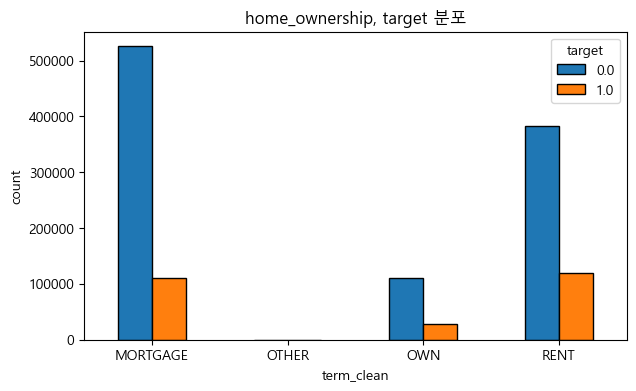

In [4]:
g_result = df.groupby(["home_ownership", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="home_ownership", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("home_ownership, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")

In [5]:

# 카이제곱 검정 
from scipy.stats import chi2_contingency
# 크로스탭 
ct_test= pd.crosstab(df['home_ownership'], df['target'])
display(ct_test)
chi2, p_value, dof, expected = chi2_contingency(ct_test)

print("기대빈도:\n", expected) 

print(f"카이제곱 통계량: {chi2:.2f}")
print(f"자유도:         {dof}")
print(f"p-value:        {p_value:.4f}, 귀무가설 기각, 주거별 부도 빈도 차이가 존재" )


n = ct_test.sum().sum()

r, c = ct_test.shape
df_star = min(r - 1, c - 1)
cramers_v = np.sqrt(chi2 / (n * df_star))

print(f"Cramér's V:     {cramers_v:.4f}, 효과크기가 무시할 정도로 미미함 ")

target,0.0,1.0
home_ownership,,
MORTGAGE,525336,110286
OTHER,305,71
OWN,110573,29019
RENT,383312,118897


기대빈도:
 [[5.07147959e+05 1.28474041e+05]
 [3.00001625e+02 7.59983753e+01]
 [1.11377199e+05 2.82148011e+04]
 [4.00700840e+05 1.01508160e+05]]
카이제곱 통계량: 6989.70
자유도:         3
p-value:        0.0000, 귀무가설 기각, 주거별 부도 빈도 차이가 존재
Cramér's V:     0.0740, 효과크기가 무시할 정도로 미미함 


In [ ]:
# 조전된 잔차
from scipy.stats import chi2_contingency
import numpy as np

# 조정된 잔차 계산
chi2, p_value, dof, expected = chi2_contingency(ct_test)

observed = ct_test.values
residuals = (observed - expected) / np.sqrt(expected)  # 표준화 잔차

# 조정된 잔차 (adjusted residuals)
n = observed.sum()
row_sums = observed.sum(axis=1, keepdims=True)
col_sums = observed.sum(axis=0, keepdims=True)
adjusted_residuals = residuals / np.sqrt((1 - row_sums/n) * (1 - col_sums/n))

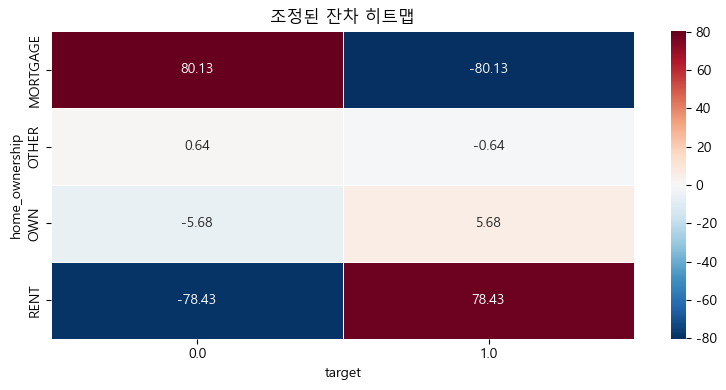

In [9]:
import seaborn as sns

adj_res_df = pd.DataFrame(
    adjusted_residuals,
    index=ct_test.index,
    columns=ct_test.columns
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    adj_res_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)
plt.title("조정된 잔차 히트맵")
plt.tight_layout()
plt.show()

# 모기지와 렌트 형태에서 유의마한 차이가 존재함 |값| > 1.96
# 렌드일시 부도 빈도가 높고, 모기지 일시 부도 빈도가 낮음

# acc_open_past_24mths
- 최근 24개월간 새로 개설한 계좌 수 
- 검증할 가설: 부도 그룹과 완납 그룹별 분포가 다른가?  

In [8]:
df.groupby("target")["acc_open_past_24mths"].agg(
    mean = "mean", 
    median = "median", 
    count ="count", 
    min = "min", 
    max = "max"
).reset_index()

,target,mean,median,count,min,max
0,0.0,4.544003,4.0,1019526,0.0,54.0
1,1.0,5.336679,5.0,258273,0.0,64.0


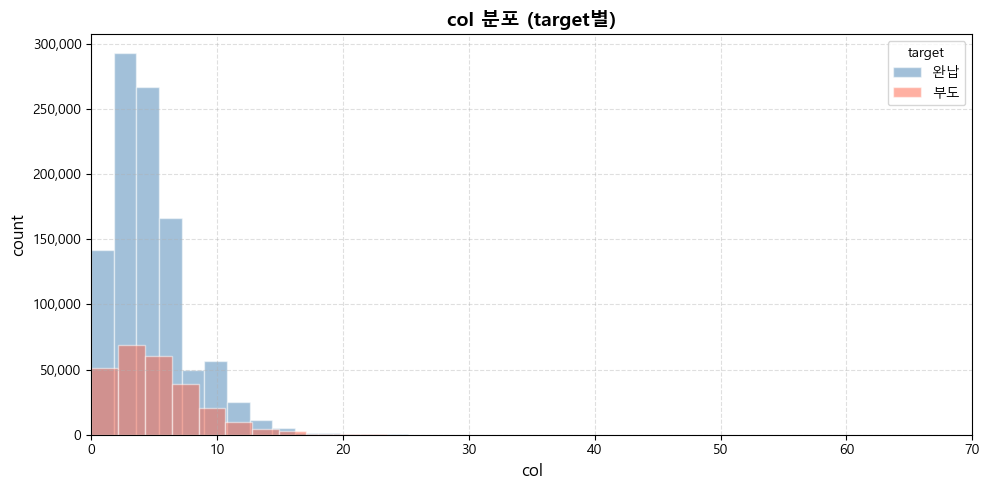

In [12]:
# 타켓 별 히스토그램 탐색 
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "완납", 1: "부도"}

fig, ax = plt.subplots(figsize=(10, 5))

for group, data in df.groupby("target")["acc_open_past_24mths"]:
    data.dropna().plot(
        kind="hist",
        alpha=0.5,
        bins=30,
        color=colors[group],
        label=labels[group],
        edgecolor="white",
        ax=ax
    )

ax.set_title("col 분포 (target별)", fontsize=14, fontweight="bold")
ax.set_xlabel("col", fontsize=12)
ax.set_ylabel("count", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="target")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(0, 70)  
plt.tight_layout()
plt.show()

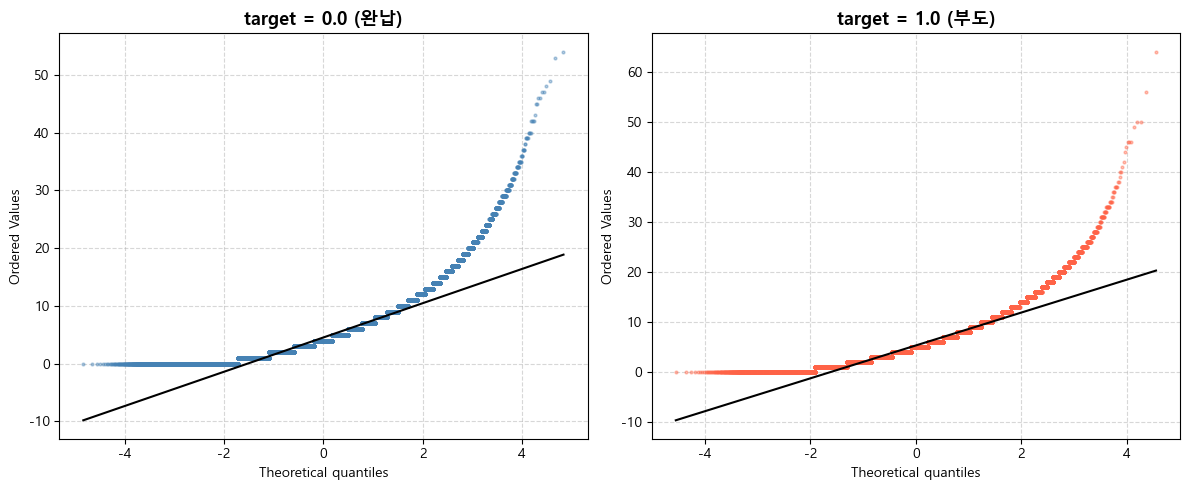

In [14]:
# 정규성 확인
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

titles = {0: "완납", 1: "부도"}
colors = {0: "steelblue", 1: "tomato"}

for ax, (group, data) in zip(axes, df.groupby("target")["acc_open_past_24mths"]):
    stats.probplot(data.dropna(), plot=ax)
    ax.get_lines()[0].set(color=colors[group], alpha=0.4, markersize=2)
    ax.get_lines()[1].set(color="black", linewidth=1.5)
    ax.set_title(f"target = {group} ({titles[group]})", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
# 비모수 검정 사용 


group_a= df[df["target"] == 0]["acc_open_past_24mths"]
group_b =df[df["target"] == 1]["acc_open_past_24mths"]

stat, p = stats.mannwhitneyu(
    x=group_a,
    y=group_b,
    alternative='two-sided'
)
print(f"p-value: {p} 귀무가설 기각, 완납그룹과 부도그룹의 신규 계좌개설 일수는 차이가 있음 ")
n1, n2 = len(group_a), len(group_b)
r = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기: {r:.2f},작은 효과, 완납그룹의 acc_open_past_24mths 가 부도그룹 보다 작은 경향," )

p-value: 0.0 귀무가설 기각, 완납그룹과 부도그룹의 신규 계좌개설 일수는 차이가 있음 
효과크기: 0.14,작은 효과, 완납그룹의 acc_open_past_24mths 가 부도그룹 보다 작은 경향,
